In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.max_columns = None

In [2]:
df = pd.read_excel('data2.xlsx')

feats = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5', 'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 
            'S2K_item_9', 'S2K_item_10', 'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14', 'S2K_item_15', 'S2K_item_16', 
            'S2K_item_17', 'S2K_item_18', 'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22', 'S2K_item_23', 'S2K_item_24']

labels = ['Cumulative_prednisolone_intake_daily_category',
        'Number_mod_severe_drugs','Drug_use_score1',
        'Drug_use_score2', 'Delta_treatment_score']




In [21]:
y_train['Delta_treatment_score'].unique()


array([0.5, 0.4, 0.6, 0.3, 0.2, 0.7, 0.8, 0. , 0.1, 1. ])

In [22]:
scaler = MinMaxScaler()

features = df.loc[:, feats]
features = features.apply(lambda x: x / 100)
targets = df.loc[:, labels]
# targets = pd.DataFrame(scaler.fit_transform(targets))
targets.columns = labels

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, shuffle=True, random_state=42)

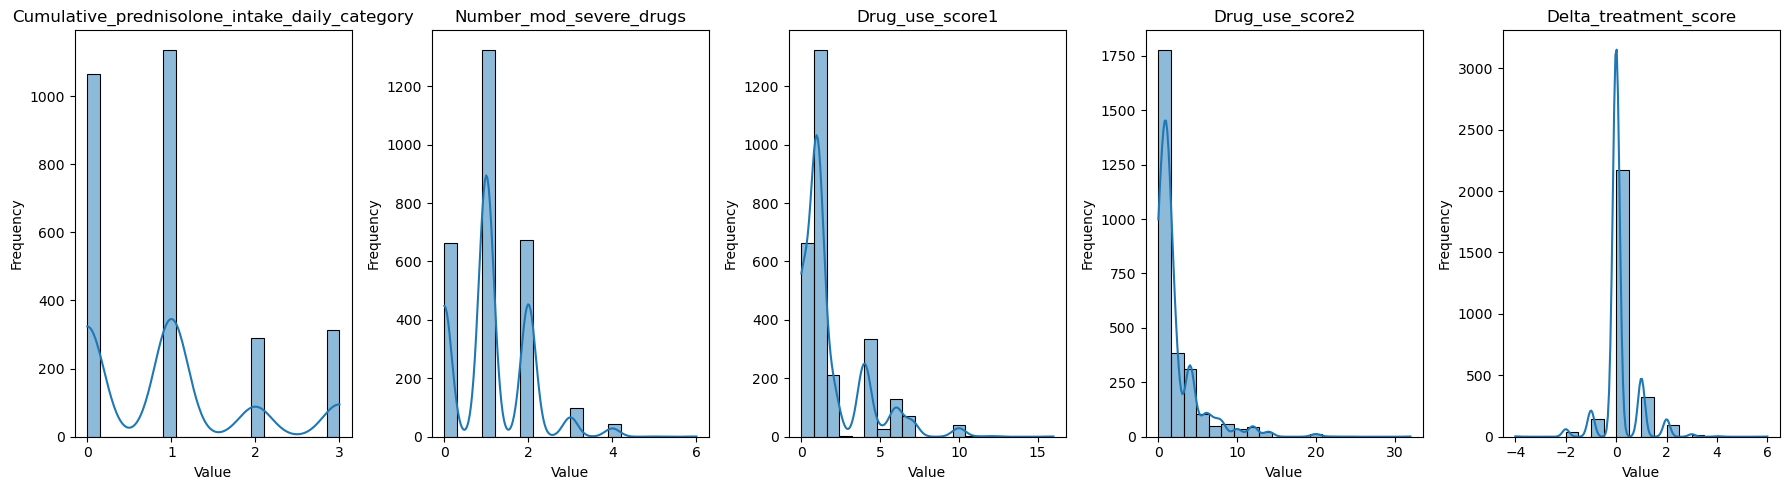

In [23]:
plt.figure(figsize=(18, 5))


# Plot histograms for each target
for i, col in enumerate(y_train.columns):
    plt.subplot(1, len(y_train.columns), i+1)
    sns.histplot(y_train.iloc[:,i], bins=20, kde=True)  # kde=True adds a density curve
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

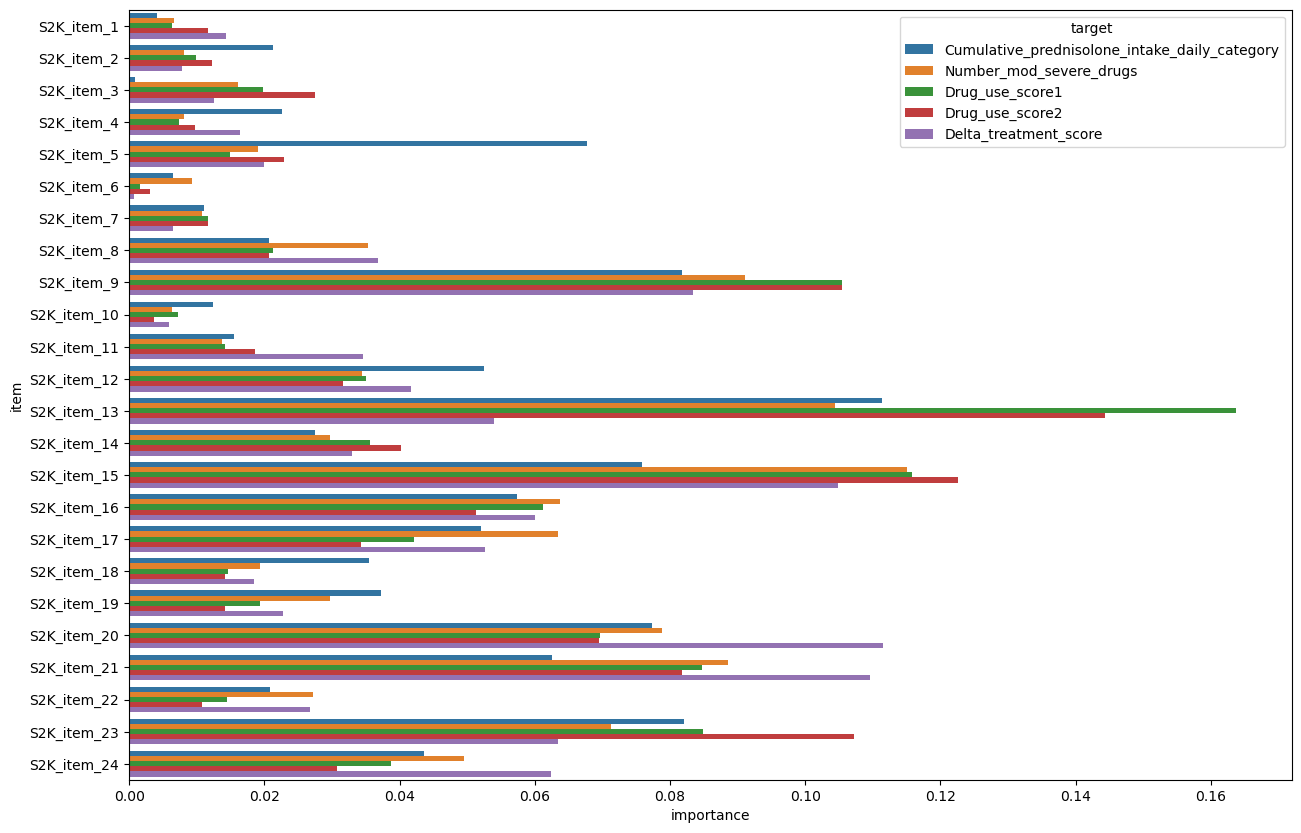

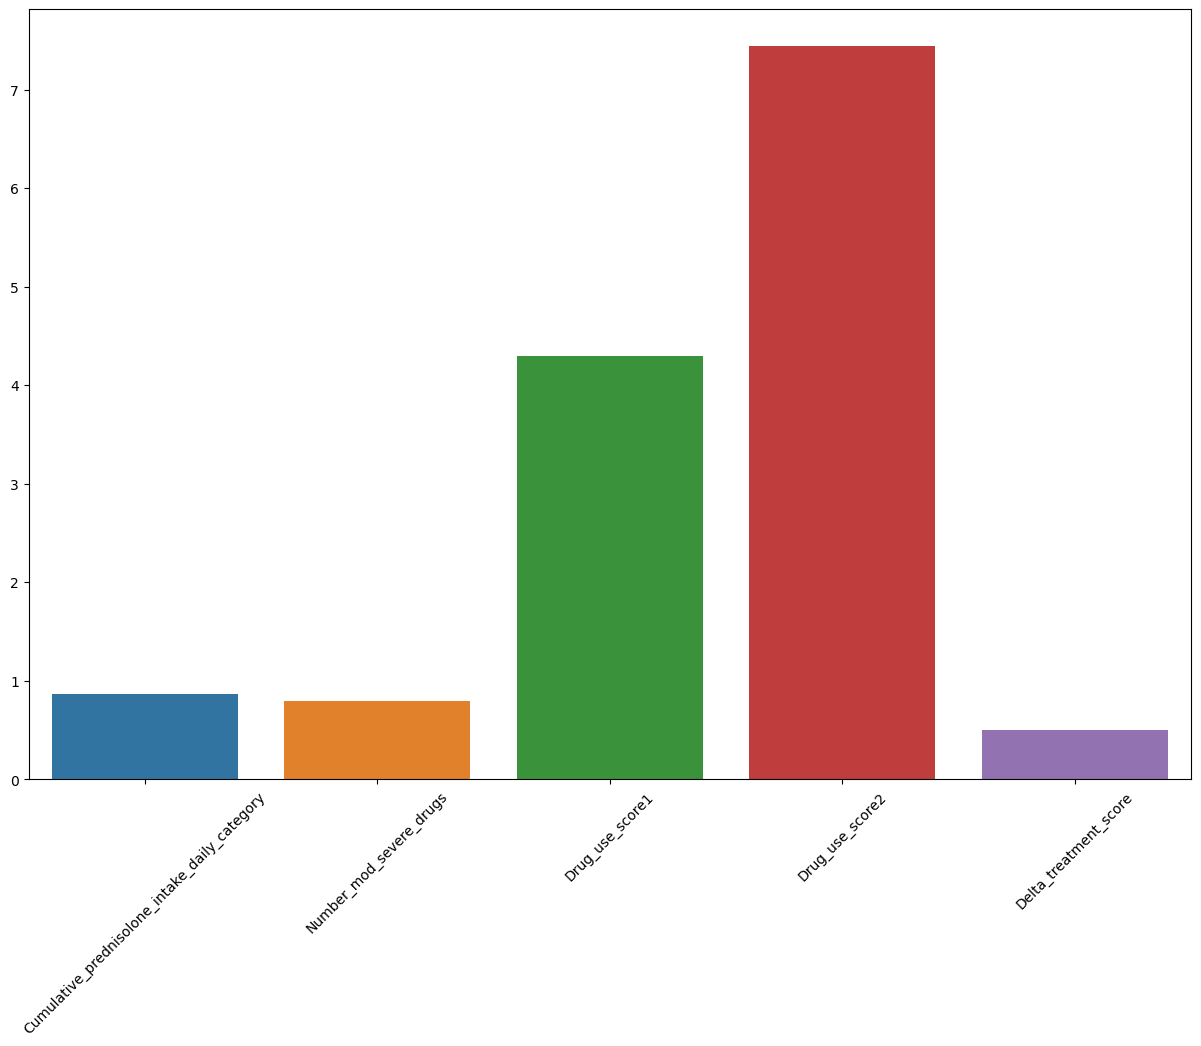

In [24]:
predn_rf = RandomForestRegressor(random_state=42)
sev_drugs_rf = RandomForestRegressor(random_state=42)
du_sc1_rf = RandomForestRegressor(random_state=42)
du_sc2_rf = RandomForestRegressor(random_state=42)
delta_treat_rf = RandomForestRegressor(random_state=42)


regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
reg_names = labels

def regressions():
    losses = {}
    importances = {}
    for i, name in zip(range(len(regressors)), reg_names):
        regressors[i].fit(X_train, y_train[name])
        preds = regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        importances[name] = regressors[i].feature_importances_
        losses[name] = loss

    return losses, importances

classification = regressions()


importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

plt.figure(figsize=(15,10))
sns.barplot(melted,x='importance',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()



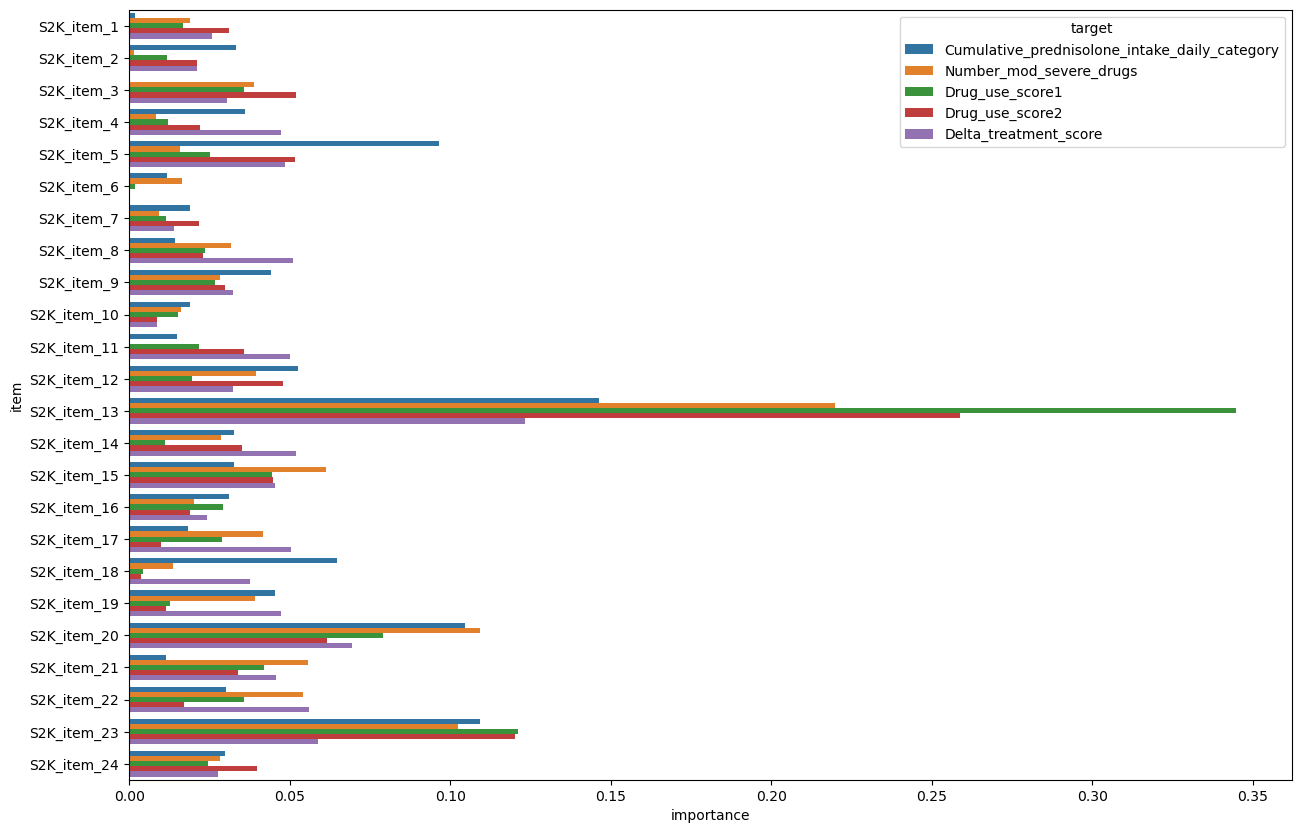

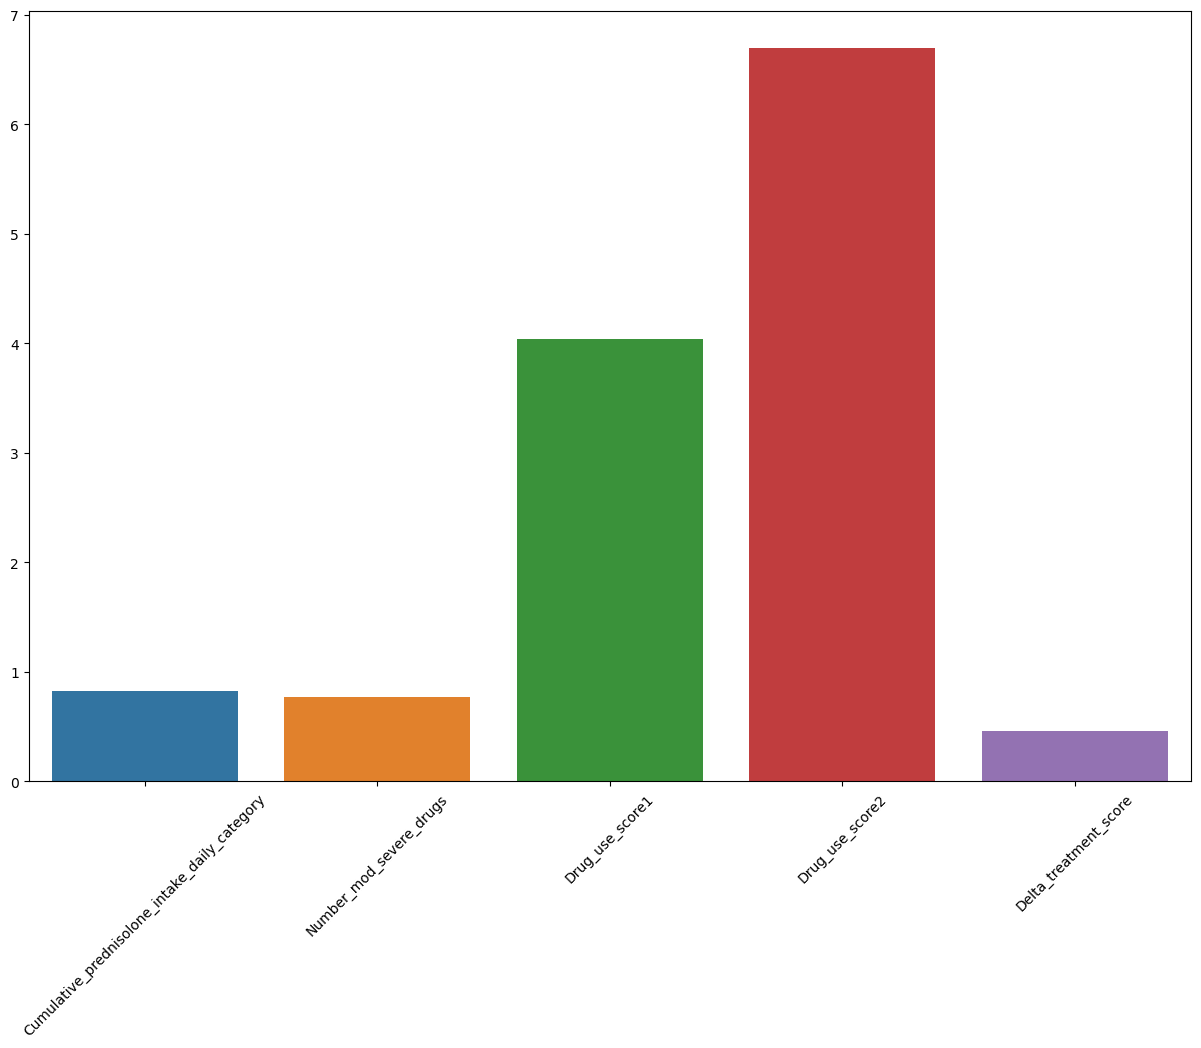

In [25]:
import xgboost

predn_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sev_drugs_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc1_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc2_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
delta_treat_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


xgb_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
xgb_reg_names = labels

def xgb():
    losses = {}
    imps = {}
    for i, name in zip(range(len(xgb_regressors)), xgb_reg_names):
        xgb_regressors[i].fit(X_train, y_train[name])
        preds = xgb_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        imps[name] = xgb_regressors[i].feature_importances_
        losses[name] = loss

    return losses, imps

classification = xgb()

importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

plt.figure(figsize=(15,10))
sns.barplot(melted,x='importance',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()


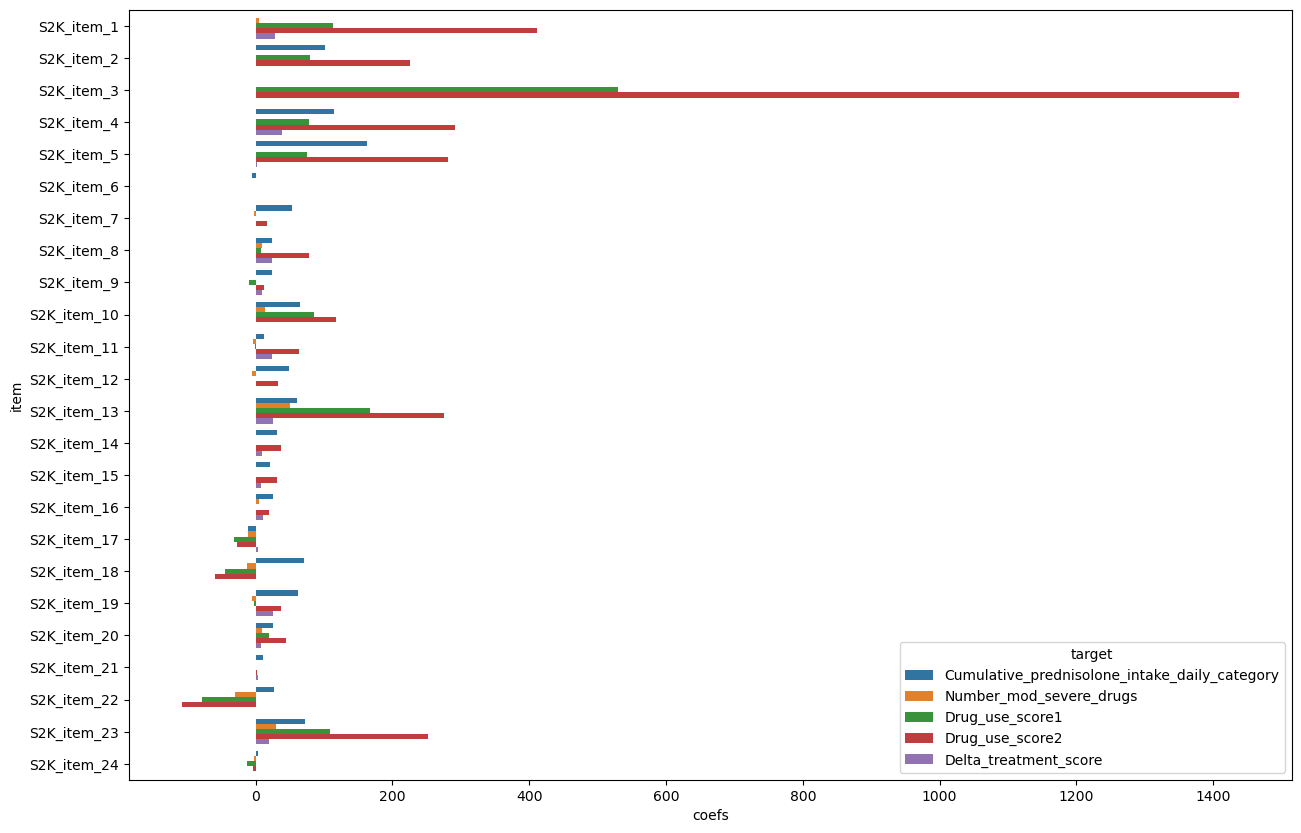

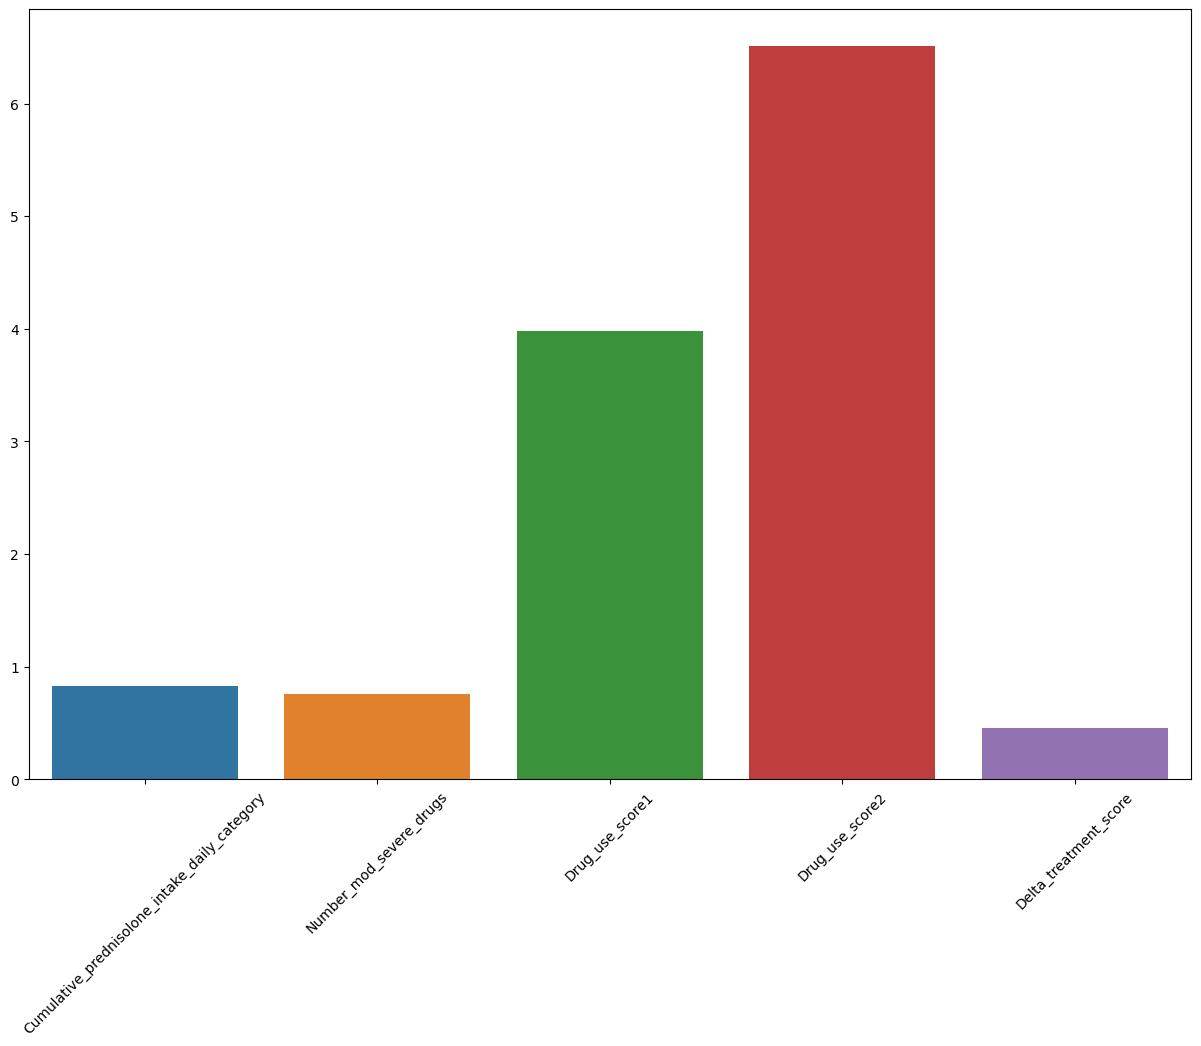

In [26]:
from sklearn.linear_model import Lasso

predn_rf = Lasso(alpha=0.00001, random_state=42)
sev_drugs_rf = Lasso(alpha=0.00001, random_state=42)
du_sc1_rf = Lasso(alpha=0.00001, random_state=42)
du_sc2_rf = Lasso(alpha=0.00001, random_state=42)
delta_treat_rf = Lasso(alpha=0.00001, random_state=42)


lasso_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
lasso_reg_names = labels

def lasso():
    losses = {}
    coefs = {}
    for i, name in zip(range(len(lasso_regressors)), lasso_reg_names):
        lasso_regressors[i].fit(X_train, y_train[name])
        preds = lasso_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        coefs[name] = lasso_regressors[i].coef_
        losses[name] = loss

    return losses, coefs

classification = lasso()
# print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')


importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','coefs']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))
plt.figure(figsize=(15,10))
sns.barplot(melted,x='coefs',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()

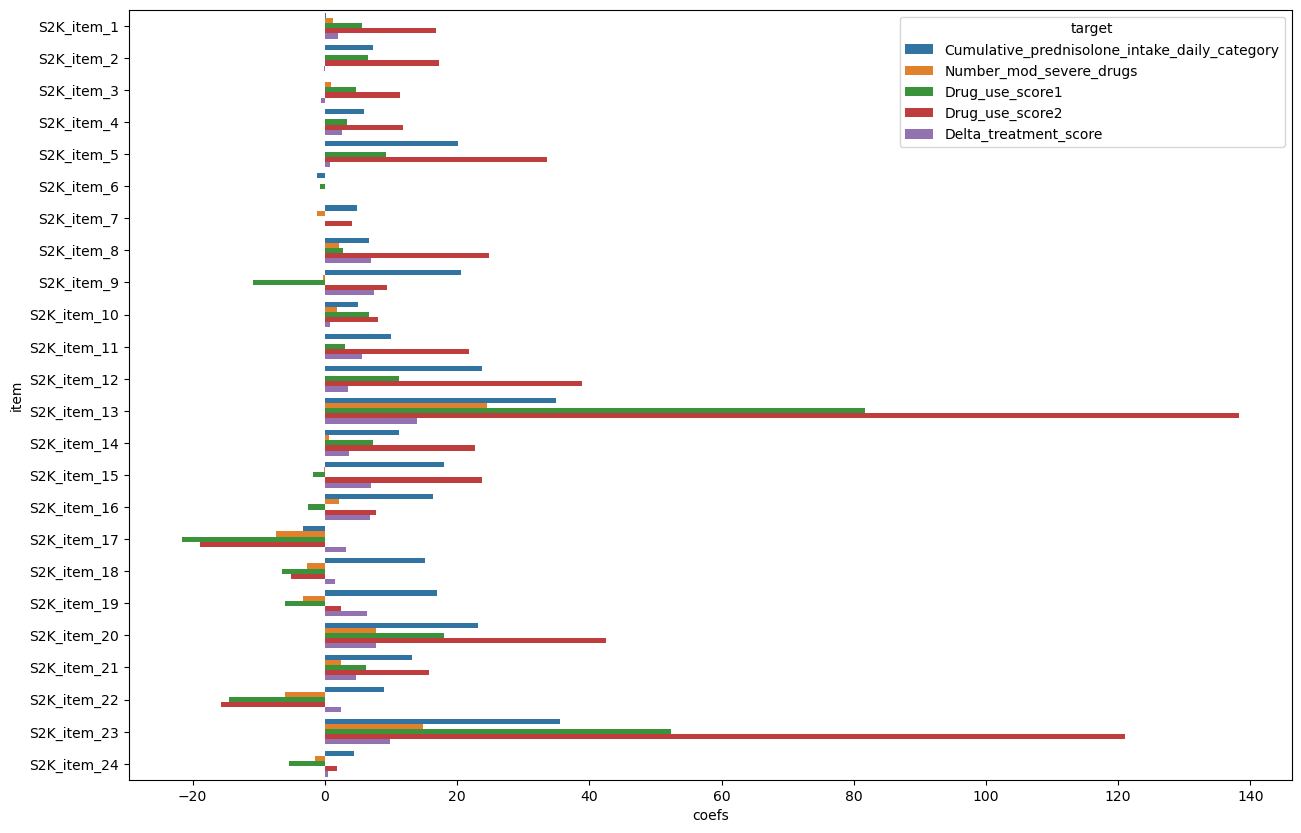

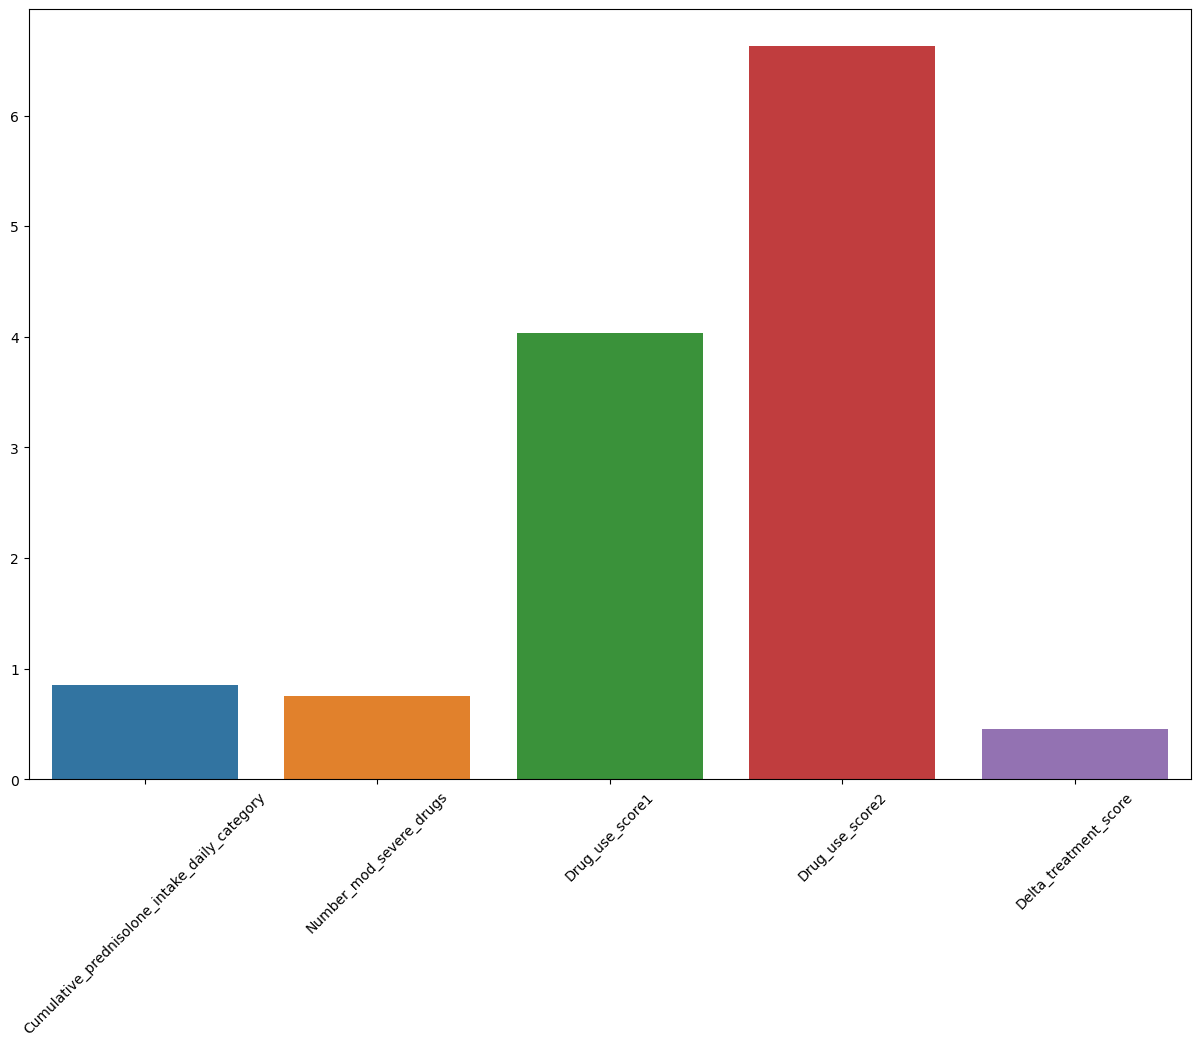

In [27]:
from sklearn.linear_model import ElasticNet

predn_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
sev_drugs_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
du_sc1_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
du_sc2_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
delta_treat_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)


elastic_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
elastic_reg_names = labels


def elastic():
    losses = {}
    imps = {}
    for i, name in zip(range(len(elastic_regressors)), elastic_reg_names):
        elastic_regressors[i].fit(X_train, y_train[name])
        preds = elastic_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        imps[name] = elastic_regressors[i].coef_
        losses[name] = loss

    return losses, imps

classification = elastic()
# print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')

importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','coefs']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))
plt.figure(figsize=(15,10))
sns.barplot(melted,x='coefs',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()